# Inventory Control & Stock Exposure Analysis

This notebook analyses the inventory-control structure of the spare-parts warehouse.

The objective is to evaluate:
- stock availability
- reorder-point exposure
- safety-stock structure
- replenishment sensitivity
- supplier lead-time impact
- operational inventory risk
- service-level support indicators

The analyses support inventory-control decisions, replenishment prioritisation, and operational warehouse monitoring.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("../outputs/as_is_inventory_control")
OUTPUT_DIR.mkdir(exist_ok=True)

part_master = pd.read_csv("../data/part_master.csv")
inventory_status = pd.read_csv("../data/inventory_status.csv")
supplier_master = pd.read_csv("../data/supplier_master.csv")

## Inventory Control Dataset

The inventory-control analysis combines material master data, inventory position, demand variability, movement class, criticality, supplier information, and replenishment parameters.

In [32]:
# Combine material, inventory, and supplier fields for inventory-control analysis
inventory_control = (
    part_master
    .merge(
        inventory_status[
            [
                "Part_ID",
                "On_Hand_Qty",
                "On_Order_Qty",
                "Allocated_Qty",
                "Available_Qty",
                "Avg_Weekly_Demand",
                "Demand_CV",
                "XYZ_Class"
            ]
        ],
        on="Part_ID",
        how="left"
    )
    .merge(
        supplier_master[
            [
                "Supplier_ID",
                "Avg_Lead_Time_Days",
                "Lead_Time_SD_Days",
                "Reliability_Score"
            ]
        ],
        on="Supplier_ID",
        how="left"
    )
)

# Estimate usable inventory value for operational prioritisation
inventory_control["Estimated_Inventory_Value"] = (
    inventory_control["Available_Qty"] *
    inventory_control["Unit_Cost_EUR"]
)

# Flag parts where available stock is below the reorder threshold
inventory_control["Below_Reorder_Point"] = (
    inventory_control["Available_Qty"] <
    inventory_control["Reorder_Point_Qty"]
)

# Estimate demand coverage using average weekly demand
inventory_control["Stock_Coverage_Weeks"] = np.where(
    inventory_control["Avg_Weekly_Demand"] > 0,
    inventory_control["Available_Qty"] / inventory_control["Avg_Weekly_Demand"],
    np.nan
)

inventory_control.head()

,Part_ID,Part_Name,Equipment_Family_ID,Equipment_Family,Equipment_Model,Part_Category_ID,Part_Category,Demand_Profile,Criticality,Supplier_ID,Supplier_Region,Unit_Cost_EUR,Storage_Type,Lifecycle_Status,Target_Service_Level,Avg_Weekly_Demand_Seed,ABC_Class,Source_Context,Movement_Class,Movement_Lines_36M,Annual_Lines,Avg_Monthly_Lines,Cumulative_Movement_%,Manual_Location,UDC_Type,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Unit_Volume_cm3,Max_Dimension_mm,Min_Dimension_mm,Stock_Managed,Avg_Daily_Qty,Lead_Time_Weeks,Safety_Stock_Qty,Reorder_Point_Qty,Max_Stock_Qty,Stock_Qty,Total_Qty_36M,Total_Volume_cm3,On_Hand_Qty,On_Order_Qty,Allocated_Qty,Available_Qty,Avg_Weekly_Demand,Demand_CV,XYZ_Class,Avg_Lead_Time_Days,Lead_Time_SD_Days,Reliability_Score,Estimated_Inventory_Value,Below_Reorder_Point,Stock_Coverage_Weeks
0,TC-CON-0343,Basic Line TC Grease Cartridge,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-015,EU,40.87,Bin,Active,0.94,4.141,A,Anonymised/reconstructed warehouse transition ...,A+,473,157.7,13.14,7.47,R-I38,VER,1543,689,68,72293,1543,68,1,2.300,1.4,18,35,48,46,1795,3470064,46,0,9,37,3.000000,1.090197,Y,10,1,0.87,1512.19,False,12.333333
1,VL-CON-0336,Scissor Lift Air Filter,VL,Vehicle Lift,Scissor Lift,CON,Consumables & service kits,frequent,Medium,SUP-004,EU,29.16,Bin,Active,0.94,4.364,A,Anonymised/reconstructed warehouse transition ...,A+,395,131.7,10.97,13.72,R-B17,D,258,91,20,470,258,20,1,1.706,1.0,13,22,38,23,1331,17860,23,0,7,16,3.852564,0.583625,X,7,3,0.95,466.56,True,4.153078
2,TC-CON-0329,A2024 LL Air Filter,TC,Tyre Changer,A2024 LL,CON,Consumables & service kits,frequent,Medium,SUP-018,EU,43.54,Bin,Active,0.94,3.839,A,Anonymised/reconstructed warehouse transition ...,A+,313,104.3,8.69,18.66,R-E25,B,61,30,42,77,61,30,1,1.272,1.3,13,22,39,23,993,3003,23,0,5,18,3.365385,0.603877,X,9,1,0.83,783.72,True,5.348571
3,WA-CON-0631,Exact Precision Lubrication Kit,WA,Wheel Aligner,Exact Precision,CON,Consumables & service kits,frequent,Medium,SUP-020,EU,26.96,Bin,Active,0.94,4.334,A,Anonymised/reconstructed warehouse transition ...,A+,231,77.0,6.42,22.31,R-F76,D,177,98,143,2480,177,98,1,0.867,1.3,15,21,32,16,677,79360,16,7,4,19,3.602564,0.587932,X,9,1,0.98,512.24,True,5.274021
4,TC-CON-0171,Basic Line TC Air Filter,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-003,EU,40.68,Bin,Active,0.94,4.441,A,Anonymised/reconstructed warehouse transition ...,A+,227,75.7,6.31,25.90,R-L86,B,135,132,46,820,135,46,1,1.030,1.0,6,12,20,17,804,16400,17,0,2,15,2.929487,1.170425,Y,6,1,0.85,610.20,False,5.120350


## Stock Position Overview

This section reviews the current stock position using on-hand, on-order, allocated, and available quantities.

The objective is to understand the operational stock base before reviewing reorder exposure and replenishment risk.

In [33]:
stock_position_summary = inventory_control[
    [
        "On_Hand_Qty",
        "On_Order_Qty",
        "Allocated_Qty",
        "Available_Qty",
        "Stock_Coverage_Weeks"
    ]
].describe().round(2)

stock_position_summary

,On_Hand_Qty,On_Order_Qty,Allocated_Qty,Available_Qty,Stock_Coverage_Weeks
count,1000.00,1000.00,1000.00,1000.00,695.00
mean,5.42,0.79,0.18,6.03,85.81
std,4.85,1.77,0.60,4.91,122.36
min,1.00,0.00,0.00,1.00,3.73
25%,2.00,0.00,0.00,3.00,18.18
50%,4.00,0.00,0.00,4.00,40.44
75%,7.00,0.00,0.00,7.00,101.64
max,46.00,18.00,9.00,37.00,1092.00


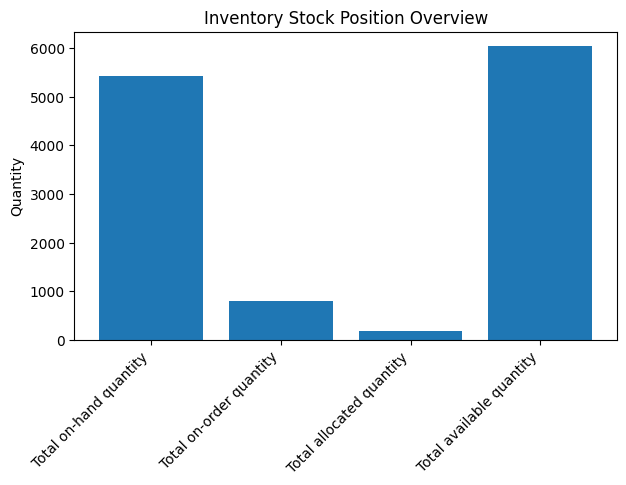

,Metric,Value
0,Total on-hand quantity,5422.00
1,Total on-order quantity,792.00
2,Total allocated quantity,180.00
3,Total available quantity,6034.00
4,Total estimated inventory value,787264.15


In [34]:
stock_totals = pd.DataFrame({
    "Metric": [
        "Total on-hand quantity",
        "Total on-order quantity",
        "Total allocated quantity",
        "Total available quantity",
        "Total estimated inventory value"
    ],
    "Value": [
        inventory_control["On_Hand_Qty"].sum(),
        inventory_control["On_Order_Qty"].sum(),
        inventory_control["Allocated_Qty"].sum(),
        inventory_control["Available_Qty"].sum(),
        round(inventory_control["Estimated_Inventory_Value"].sum(), 2)
    ]
})

plt.figure(figsize=(7,4))

stock_totals_plot = stock_totals.iloc[:4]

plt.bar(
    stock_totals_plot["Metric"],
    stock_totals_plot["Value"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Quantity")
plt.title("Inventory Stock Position Overview")

plt.show()

stock_totals

## Reorder-Point Exposure

This section identifies parts where available stock is below the reorder point.

These items represent operational replenishment exposure and should be reviewed before purchase requisition or replenishment decisions are made.

In [35]:
reorder_exposure_summary = pd.DataFrame({
    "Metric": [
        "Total parts",
        "Parts below reorder point",
        "Below reorder point %",
        "Critical parts below reorder point",
        "High-movement parts below reorder point"
    ],
    "Value": [
        len(inventory_control),
        inventory_control["Below_Reorder_Point"].sum(),
        round(inventory_control["Below_Reorder_Point"].mean() * 100, 2),
        inventory_control[
            (inventory_control["Below_Reorder_Point"]) &
            (inventory_control["Criticality"] == "Critical")
        ]["Part_ID"].nunique(),
        inventory_control[
            (inventory_control["Below_Reorder_Point"]) &
            (inventory_control["Movement_Class"].isin(["A+", "A", "B"]))
        ]["Part_ID"].nunique()
    ]
})

reorder_exposure_summary

,Metric,Value
0,Total parts,1000.0
1,Parts below reorder point,47.0
2,Below reorder point %,4.7
3,Critical parts below reorder point,3.0
4,High-movement parts below reorder point,17.0


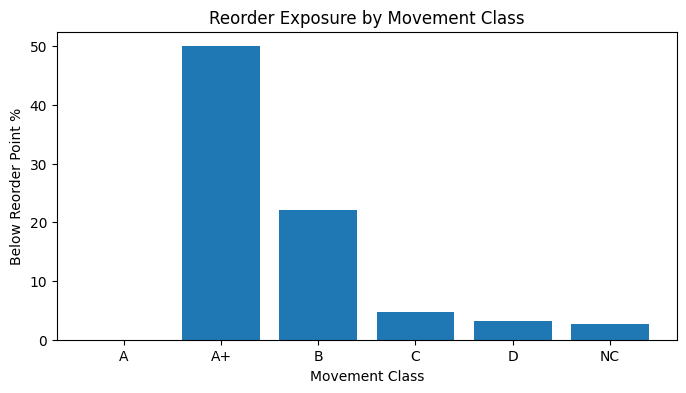

,Movement_Class,Parts,Parts_Below_Reorder,Avg_Available_Qty,Avg_Reorder_Point,Below_Reorder_%
0,A,9,0,14.56,11.78,0.00
1,A+,8,4,23.88,22.12,50.00
2,B,59,13,14.86,12.51,22.03
3,C,167,8,10.75,7.72,4.79
4,D,338,11,5.15,3.53,3.25
5,NC,419,11,3.10,2.13,2.63


In [36]:
reorder_by_movement = (
    inventory_control
    .groupby("Movement_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Parts_Below_Reorder=("Below_Reorder_Point", "sum"),
        Avg_Available_Qty=("Available_Qty", "mean"),
        Avg_Reorder_Point=("Reorder_Point_Qty", "mean")
    )
    .round(2)
    .reset_index()
)

reorder_by_movement["Below_Reorder_%"] = (
    reorder_by_movement["Parts_Below_Reorder"] /
    reorder_by_movement["Parts"] * 100
).round(2)

plt.figure(figsize=(8,4))

plt.bar(
    reorder_by_movement["Movement_Class"],
    reorder_by_movement["Below_Reorder_%"]
)

plt.xlabel("Movement Class")
plt.ylabel("Below Reorder Point %")
plt.title("Reorder Exposure by Movement Class")

plt.show()

reorder_by_movement

In [37]:
reorder_by_abc = (
    inventory_control
    .groupby("ABC_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Parts_Below_Reorder=("Below_Reorder_Point", "sum"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean")
    )
    .round(2)
    .reset_index()
)

reorder_by_abc["Below_Reorder_%"] = (
    reorder_by_abc["Parts_Below_Reorder"] /
    reorder_by_abc["Parts"] * 100
).round(2)

reorder_by_abc

,ABC_Class,Parts,Parts_Below_Reorder,Avg_Inventory_Value,Below_Reorder_%
0,A,449,18,1434.28,4.01
1,B,295,13,387.32,4.41
2,C,256,16,113.35,6.25


## Safety Stock Review

Safety stock is reviewed against demand variability, movement class, and criticality.

The objective is to identify whether higher-risk or more variable items have appropriate inventory buffers.

In [38]:
safety_stock_summary = (
    inventory_control
    .groupby("XYZ_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Safety_Stock=("Safety_Stock_Qty", "mean"),
        Avg_Demand_CV=("Demand_CV", "mean"),
        Avg_Weekly_Demand=("Avg_Weekly_Demand", "mean"),
        Avg_Target_Service_Level=("Target_Service_Level", "mean")
    )
    .round(2)
    .reset_index()
)

safety_stock_summary

,XYZ_Class,Parts,Avg_Safety_Stock,Avg_Demand_CV,Avg_Weekly_Demand,Avg_Target_Service_Level
0,X,11,9.09,0.73,2.82,0.94
1,Y,169,5.36,1.80,0.81,0.93
2,Z,820,1.86,6.21,0.07,0.95


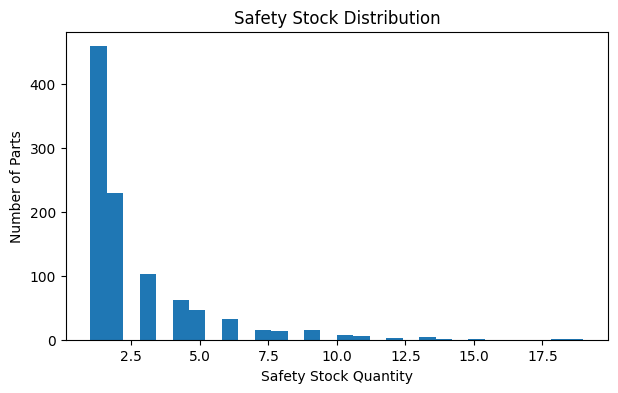

,Criticality,Parts,Avg_Safety_Stock,Avg_Reorder_Point,Avg_Target_Service_Level
0,Critical,139,1.43,2.57,0.98
1,High,333,2.11,3.61,0.97
2,Low,163,2.92,5.34,0.90
3,Medium,365,3.16,5.38,0.94


In [39]:
critical_safety_stock = (
    inventory_control
    .groupby("Criticality")
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Safety_Stock=("Safety_Stock_Qty", "mean"),
        Avg_Reorder_Point=("Reorder_Point_Qty", "mean"),
        Avg_Target_Service_Level=("Target_Service_Level", "mean")
    )
    .round(2)
    .reset_index()
)

plt.figure(figsize=(7,4))

plt.hist(
    inventory_control["Safety_Stock_Qty"],
    bins=30
)

plt.xlabel("Safety Stock Quantity")
plt.ylabel("Number of Parts")
plt.title("Safety Stock Distribution")

plt.show()

critical_safety_stock

## Lead-Time Exposure

Supplier lead time affects reorder timing, safety stock, and replenishment sensitivity.

This section reviews lead-time exposure by supplier region and identifies where longer or more variable lead times may increase inventory-control risk.

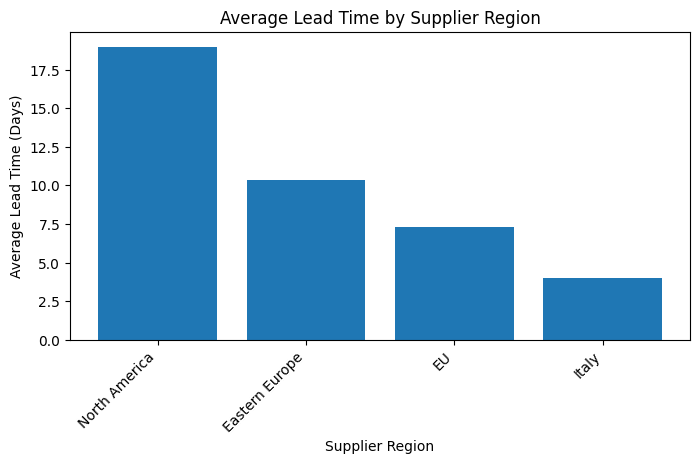

,Supplier_Region,Parts,Avg_Lead_Time_Days,Avg_Lead_Time_SD_Days,Avg_Reliability_Score,Parts_Below_Reorder
3,North America,62,19.00,3.00,0.86,2
1,Eastern Europe,154,10.36,1.71,0.81,7
0,EU,604,7.31,1.60,0.91,33
2,Italy,180,4.00,1.25,0.87,5


In [40]:
lead_time_by_region = (
    inventory_control
    .groupby("Supplier_Region")
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Lead_Time_Days=("Avg_Lead_Time_Days", "mean"),
        Avg_Lead_Time_SD_Days=("Lead_Time_SD_Days", "mean"),
        Avg_Reliability_Score=("Reliability_Score", "mean"),
        Parts_Below_Reorder=("Below_Reorder_Point", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("Avg_Lead_Time_Days", ascending=False)
)

plt.figure(figsize=(8,4))

plt.bar(
    lead_time_by_region["Supplier_Region"],
    lead_time_by_region["Avg_Lead_Time_Days"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Supplier Region")
plt.ylabel("Average Lead Time (Days)")
plt.title("Average Lead Time by Supplier Region")

plt.show()

lead_time_by_region

## Critical Inventory Exposure

Critical spare parts require higher operational visibility because stockouts may affect maintenance continuity, service capability, or equipment availability.

This section identifies critical inventory with replenishment or stock-coverage exposure.

In [41]:
critical_exposure = inventory_control[
    (inventory_control["Criticality"] == "Critical") &
    (
        (inventory_control["Below_Reorder_Point"]) |
        (inventory_control["Stock_Coverage_Weeks"] <= inventory_control["Lead_Time_Weeks"])
    )
].copy()

critical_exposure[
    [
        "Part_ID",
        "Part_Name",
        "Movement_Class",
        "ABC_Class",
        "XYZ_Class",
        "Supplier_Region",
        "Available_Qty",
        "Reorder_Point_Qty",
        "Stock_Coverage_Weeks",
        "Lead_Time_Weeks",
        "Estimated_Inventory_Value"
    ]
].head(20)

,Part_ID,Part_Name,Movement_Class,ABC_Class,XYZ_Class,Supplier_Region,Available_Qty,Reorder_Point_Qty,Stock_Coverage_Weeks,Lead_Time_Weeks,Estimated_Inventory_Value
187,WB-CON-0955,EM 9000 Rubber Pad,C,B,Y,Italy,6,7,12.155844,1.0,108.3
535,VL-CON-0284,Alignment Lift Service Seal Pack,D,B,Z,Italy,6,7,52.000000,1.0,178.5
911,TC-PCB-0524,A2024 LL I/O Board,NC,A,Z,EU,1,2,NaN,1.1,1230.0


In [42]:
critical_exposure_summary = (
    critical_exposure
    .groupby(["Movement_Class", "ABC_Class", "XYZ_Class"])
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Available_Qty=("Available_Qty", "mean"),
        Avg_Reorder_Point=("Reorder_Point_Qty", "mean"),
        Avg_Stock_Coverage_Weeks=("Stock_Coverage_Weeks", "mean"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean")
    )
    .round(2)
    .reset_index()
)

critical_exposure_summary

,Movement_Class,ABC_Class,XYZ_Class,Parts,Avg_Available_Qty,Avg_Reorder_Point,Avg_Stock_Coverage_Weeks,Avg_Inventory_Value
0,C,B,Y,1,6.0,7.0,12.16,108.3
1,D,B,Z,1,6.0,7.0,52.00,178.5
2,NC,A,Z,1,1.0,2.0,NaN,1230.0


## Stock Coverage Review

Stock coverage estimates how many weeks of demand can be covered by currently available stock.

This metric is useful for operational monitoring, but it should be interpreted carefully for intermittent spare parts where average demand may be low or irregular.

In [43]:
coverage_summary = (
    inventory_control
    .replace([np.inf, -np.inf], np.nan)
    .groupby("Movement_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Avg_Stock_Coverage_Weeks=("Stock_Coverage_Weeks", "mean"),
        Median_Stock_Coverage_Weeks=("Stock_Coverage_Weeks", "median"),
        Parts_Below_Reorder=("Below_Reorder_Point", "sum")
    )
    .round(2)
    .reset_index()
)

coverage_summary

,Movement_Class,Parts,Avg_Stock_Coverage_Weeks,Median_Stock_Coverage_Weeks,Parts_Below_Reorder
0,A,9,6.37,6.40,0
1,A+,8,7.96,6.43,4
2,B,59,14.67,12.84,13
3,C,167,29.84,23.74,8
4,D,338,76.38,52.00,11
5,NC,419,244.32,156.00,11


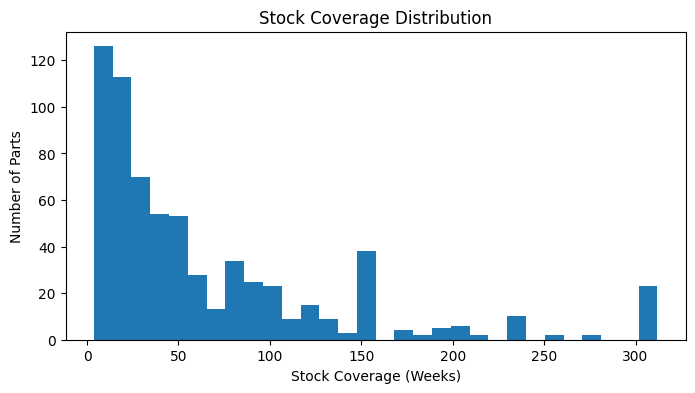

In [44]:
coverage_plot_data = inventory_control[
    inventory_control["Stock_Coverage_Weeks"].notna()
].copy()

coverage_plot_data = coverage_plot_data[
    coverage_plot_data["Stock_Coverage_Weeks"] <=
    coverage_plot_data["Stock_Coverage_Weeks"].quantile(0.95)
]

plt.figure(figsize=(8,4))

plt.hist(
    coverage_plot_data["Stock_Coverage_Weeks"],
    bins=30
)

plt.xlabel("Stock Coverage (Weeks)")
plt.ylabel("Number of Parts")
plt.title("Stock Coverage Distribution")

plt.show()

In [ ]:
reorder_exposure_summary.to_csv(
    OUTPUT_DIR / "reorder_exposure_summary.csv",
    index=False
)

reorder_by_movement.to_csv(
    OUTPUT_DIR / "reorder_by_movement.csv",
    index=False
)

lead_time_by_region.to_csv(
    OUTPUT_DIR / "lead_time_by_region.csv",
    index=False
)

critical_exposure.to_csv(
    OUTPUT_DIR / "critical_inventory_exposure.csv",
    index=False
)

coverage_summary.to_csv(
    OUTPUT_DIR / "stock_coverage_by_movement.csv",
    index=False
)

## Inventory Control Observations

The inventory-control analysis highlights the relationship between stock availability, reorder points, safety stock, lead time, and operational criticality.

The results support:
- identification of parts exposed to reorder-point risk
- review of safety-stock structure across demand variability classes
- supplier lead-time exposure analysis
- prioritisation of critical parts requiring closer monitoring
- stock-coverage monitoring by movement class

These findings provide the operational basis for the following replenishment workflow and ERP-style inventory monitoring analyses.